# Chapter 7 - TTA Implementation
May 29, 2021<br>
Vishal Bakshi


In [1]:
#hide
from IPython.display import HTML

Here's a video walkthrough of this notebook:

In [5]:
HTML('<iframe width="560" height="315" src="https://www.youtube.com/embed/3g5YLK1nbu8" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>')

## Introduction

In this notebook, I work through the first of four "Further Research" problems assigned at the end of Chapter 7 in the textbook "Deep Learning for Coders with fastai and PyTorch".

The prompt for this exercise is:

>Use the fastai documentation to build a function that crops an image to a square in each of the four corners; then implement a TTA method that averages the predictions on a center crop and those four crops. Did it help? Is it better than the TTA method of fastai?

## What is Test Time Augmentation?

I'll quote directly from the text:

>During inference or validation, creating multiple versions of each image using data augmentation, and then taking the average or maximum of the predictions for each augmented version of the image.

TTA is data augmentation during validation, in hopes that objects located outside the center of the image (which is the default fastai validation image crop) can be recognized by the model in order to increase the model's accuracy.

The default `Learner.tta` method averages the predictions on the center crop and four randomly generated crops. The method I'll create will average the predictions between the center crop and four corner crops.

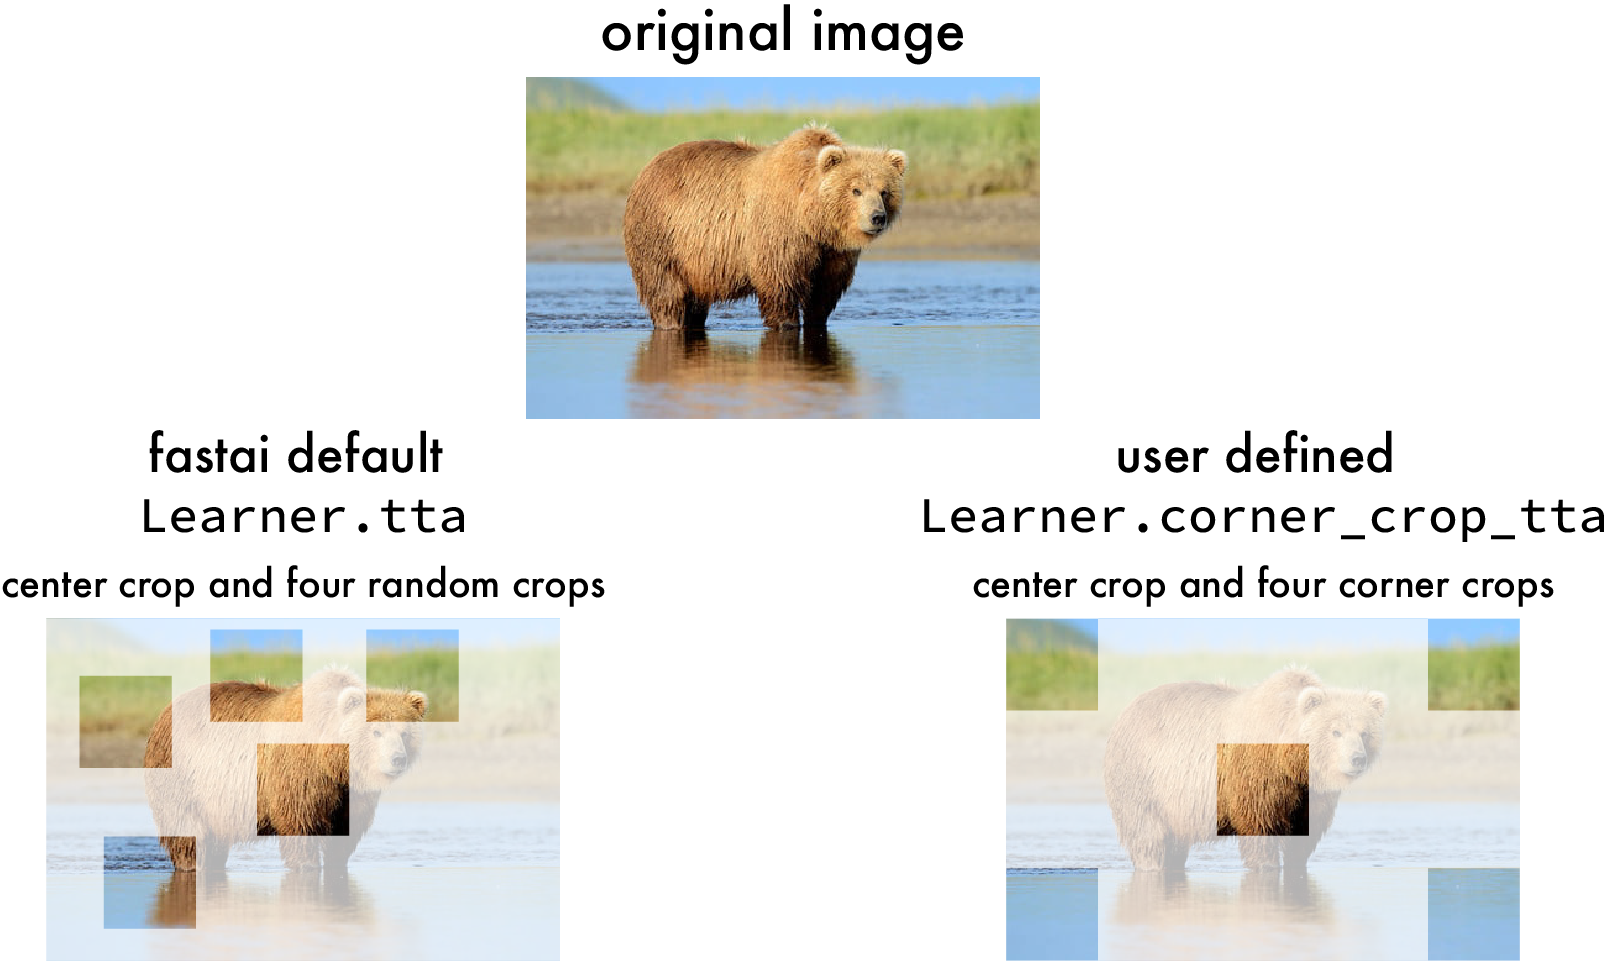

## User-defined Test Time Augmentation

### Read and understand the [`Learner.tta`](https://github.com/fastai/fastai/blob/master/fastai/learner.py#L576) and [`RandomCrop`](https://github.com/fastai/fastai/blob/master/fastai/vision/augment.py#L164) source code

```python
def tta(self:Learner, ds_idx=1, dl=None, n=4, item_tfms=None, batch_tfms=None, beta=0.25, use_max=False):
    "Return predictions on the `ds_idx` dataset or `dl` using Test Time Augmentation"
    if dl is None: dl = self.dls[ds_idx].new(shuffled=False, drop_last=False)
    if item_tfms is not None or batch_tfms is not None: dl = dl.new(after_item=item_tfms, after_batch=batch_tfms)
    try:
        self(_before_epoch)
        with dl.dataset.set_split_idx(0), self.no_mbar():
            if hasattr(self,'progress'): self.progress.mbar = master_bar(list(range(n)))
            aug_preds = []
            for i in self.progress.mbar if hasattr(self,'progress') else range(n):
                self.epoch = i #To keep track of progress on mbar since the progress callback will use self.epoch
                aug_preds.append(self.get_preds(dl=dl, inner=True)[0][None])
        aug_preds = torch.cat(aug_preds)
        aug_preds = aug_preds.max(0)[0] if use_max else aug_preds.mean(0)
        self.epoch = n
        with dl.dataset.set_split_idx(1): preds,targs = self.get_preds(dl=dl, inner=True)
    finally: self(event.after_fit)

    if use_max: return torch.stack([preds, aug_preds], 0).max(0)[0],targs
    preds = (aug_preds,preds) if beta is None else torch.lerp(aug_preds, preds, beta)
    return preds,targs

```

```python
class RandomCrop(RandTransform):
    "Randomly crop an image to `size`"
    split_idx,order = None,1
    def __init__(self, size, **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx):
        self.orig_sz = _get_sz(b)
        if split_idx: self.tl = (self.orig_sz-self.size)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.tl = fastuple(random.randint(*w_rand), random.randint(*h_rand))

    def encodes(self, x:(Image.Image,TensorBBox,TensorPoint)):
        return x.crop_pad(self.size, self.tl, orig_sz=self.orig_sz)

```

In [ ]:
#hide
!pip install -Uqq fastai 
!pip install -Uqq fastcore

In [ ]:
#hide
import fastai
fastai.__version__=='2.3.1'

In [ ]:
#hide
from fastai.vision.all import *

In [ ]:
#hide
from google.colab import drive
drive.mount('/content/gdrive')

### Practice cropping images using the `.crop` method on a `PILImage` object

A `PIL` `Image` has a method called `crop` which takes a crop rectangle tuple, `(left, upper, right, lower)` and crops the image within those pixel bounds.

I'll use it on a test image from my Google Drive to take a `224` x `224` pixel crop from each corner, and the center of the image.

In [ ]:
f = "/content/gdrive/MyDrive/fastai-course-v4/images/test/grizzly_black.png"
img = PILImage.create(f)
img.to_thumb(320)

#### Top-Left Corner Crop

In [ ]:
img.crop((0,0,224,224))

#### Top Right Corner Crop

In [ ]:
w = img.width
h = img.height
img.crop((w-224, 0, w, 224))

#### Bottom Right Corner Crop

In [ ]:
img.crop((w-224, h-224, w, h))

#### Bottom Left Corner Crop

In [ ]:
img.crop((0, h-224, 224, h))

#### Center Crop

In [ ]:
img.crop((w/2-112, h/2-112, w/2+112,h/2+112))

#### Summary

_Summary of corner `crop` arguments `(left, upper, right, bottom)`_



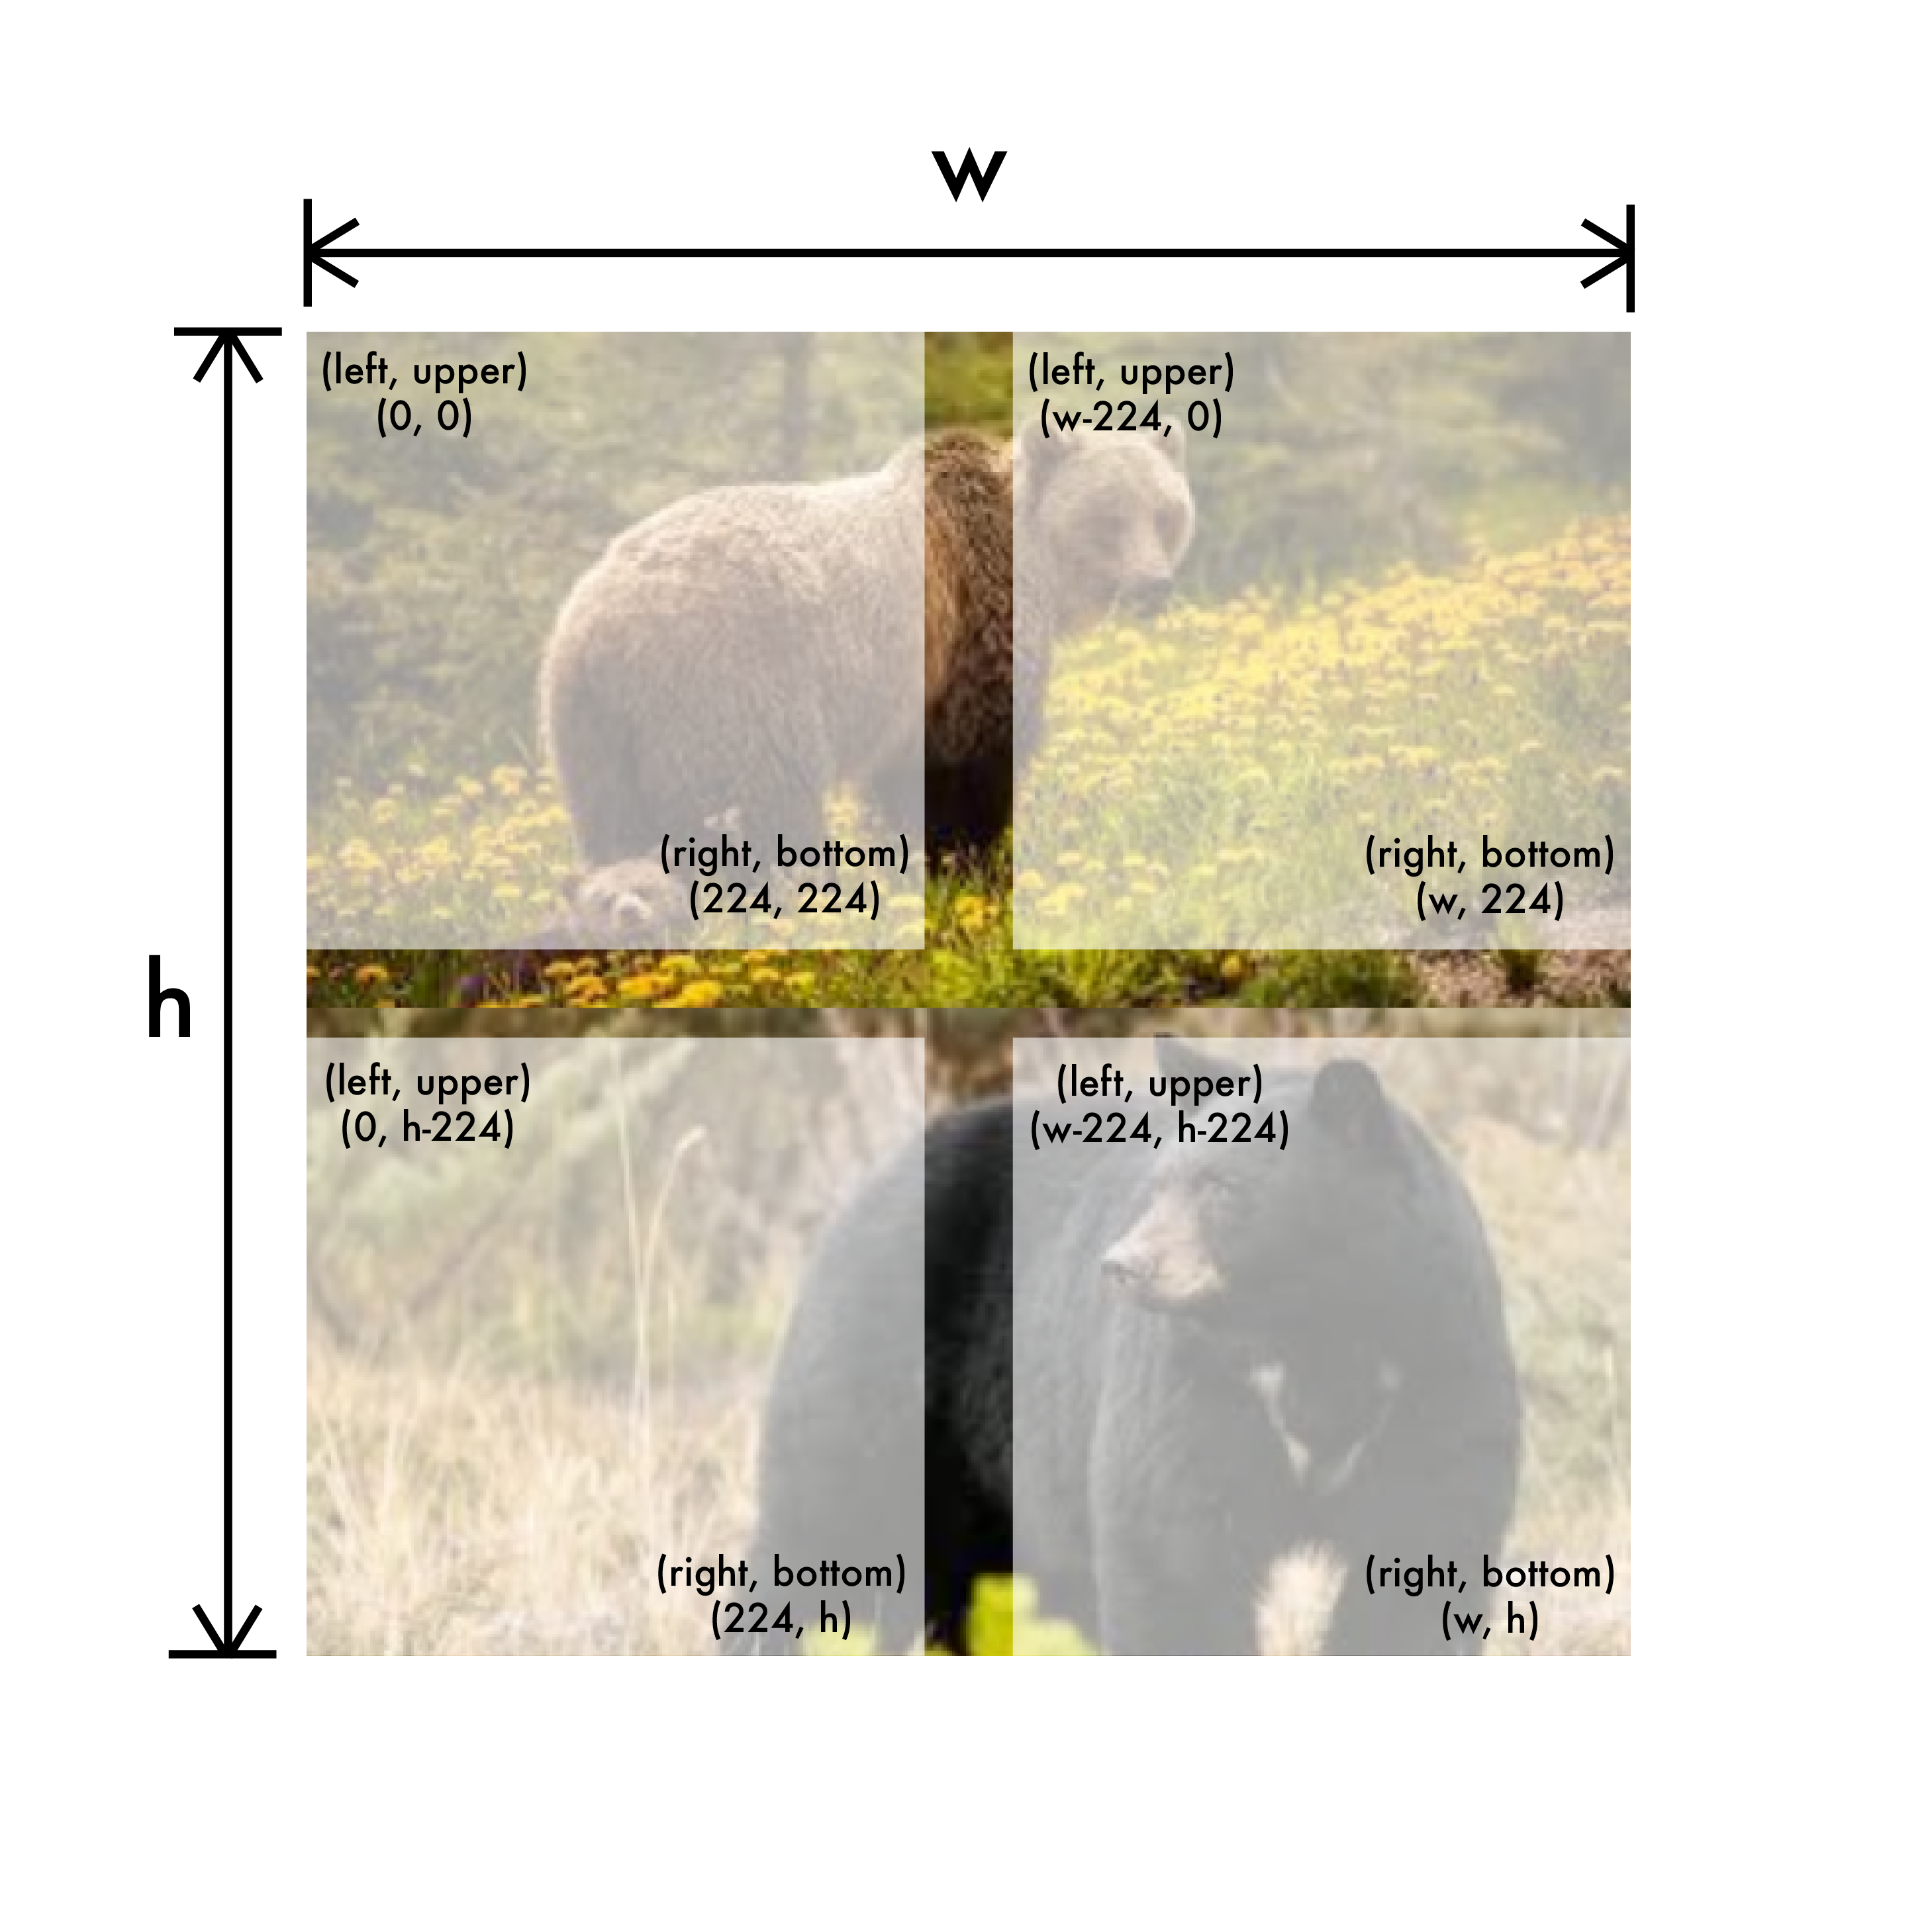

_Summary of center `crop` arguments `(left, upper, right, bottom)`_



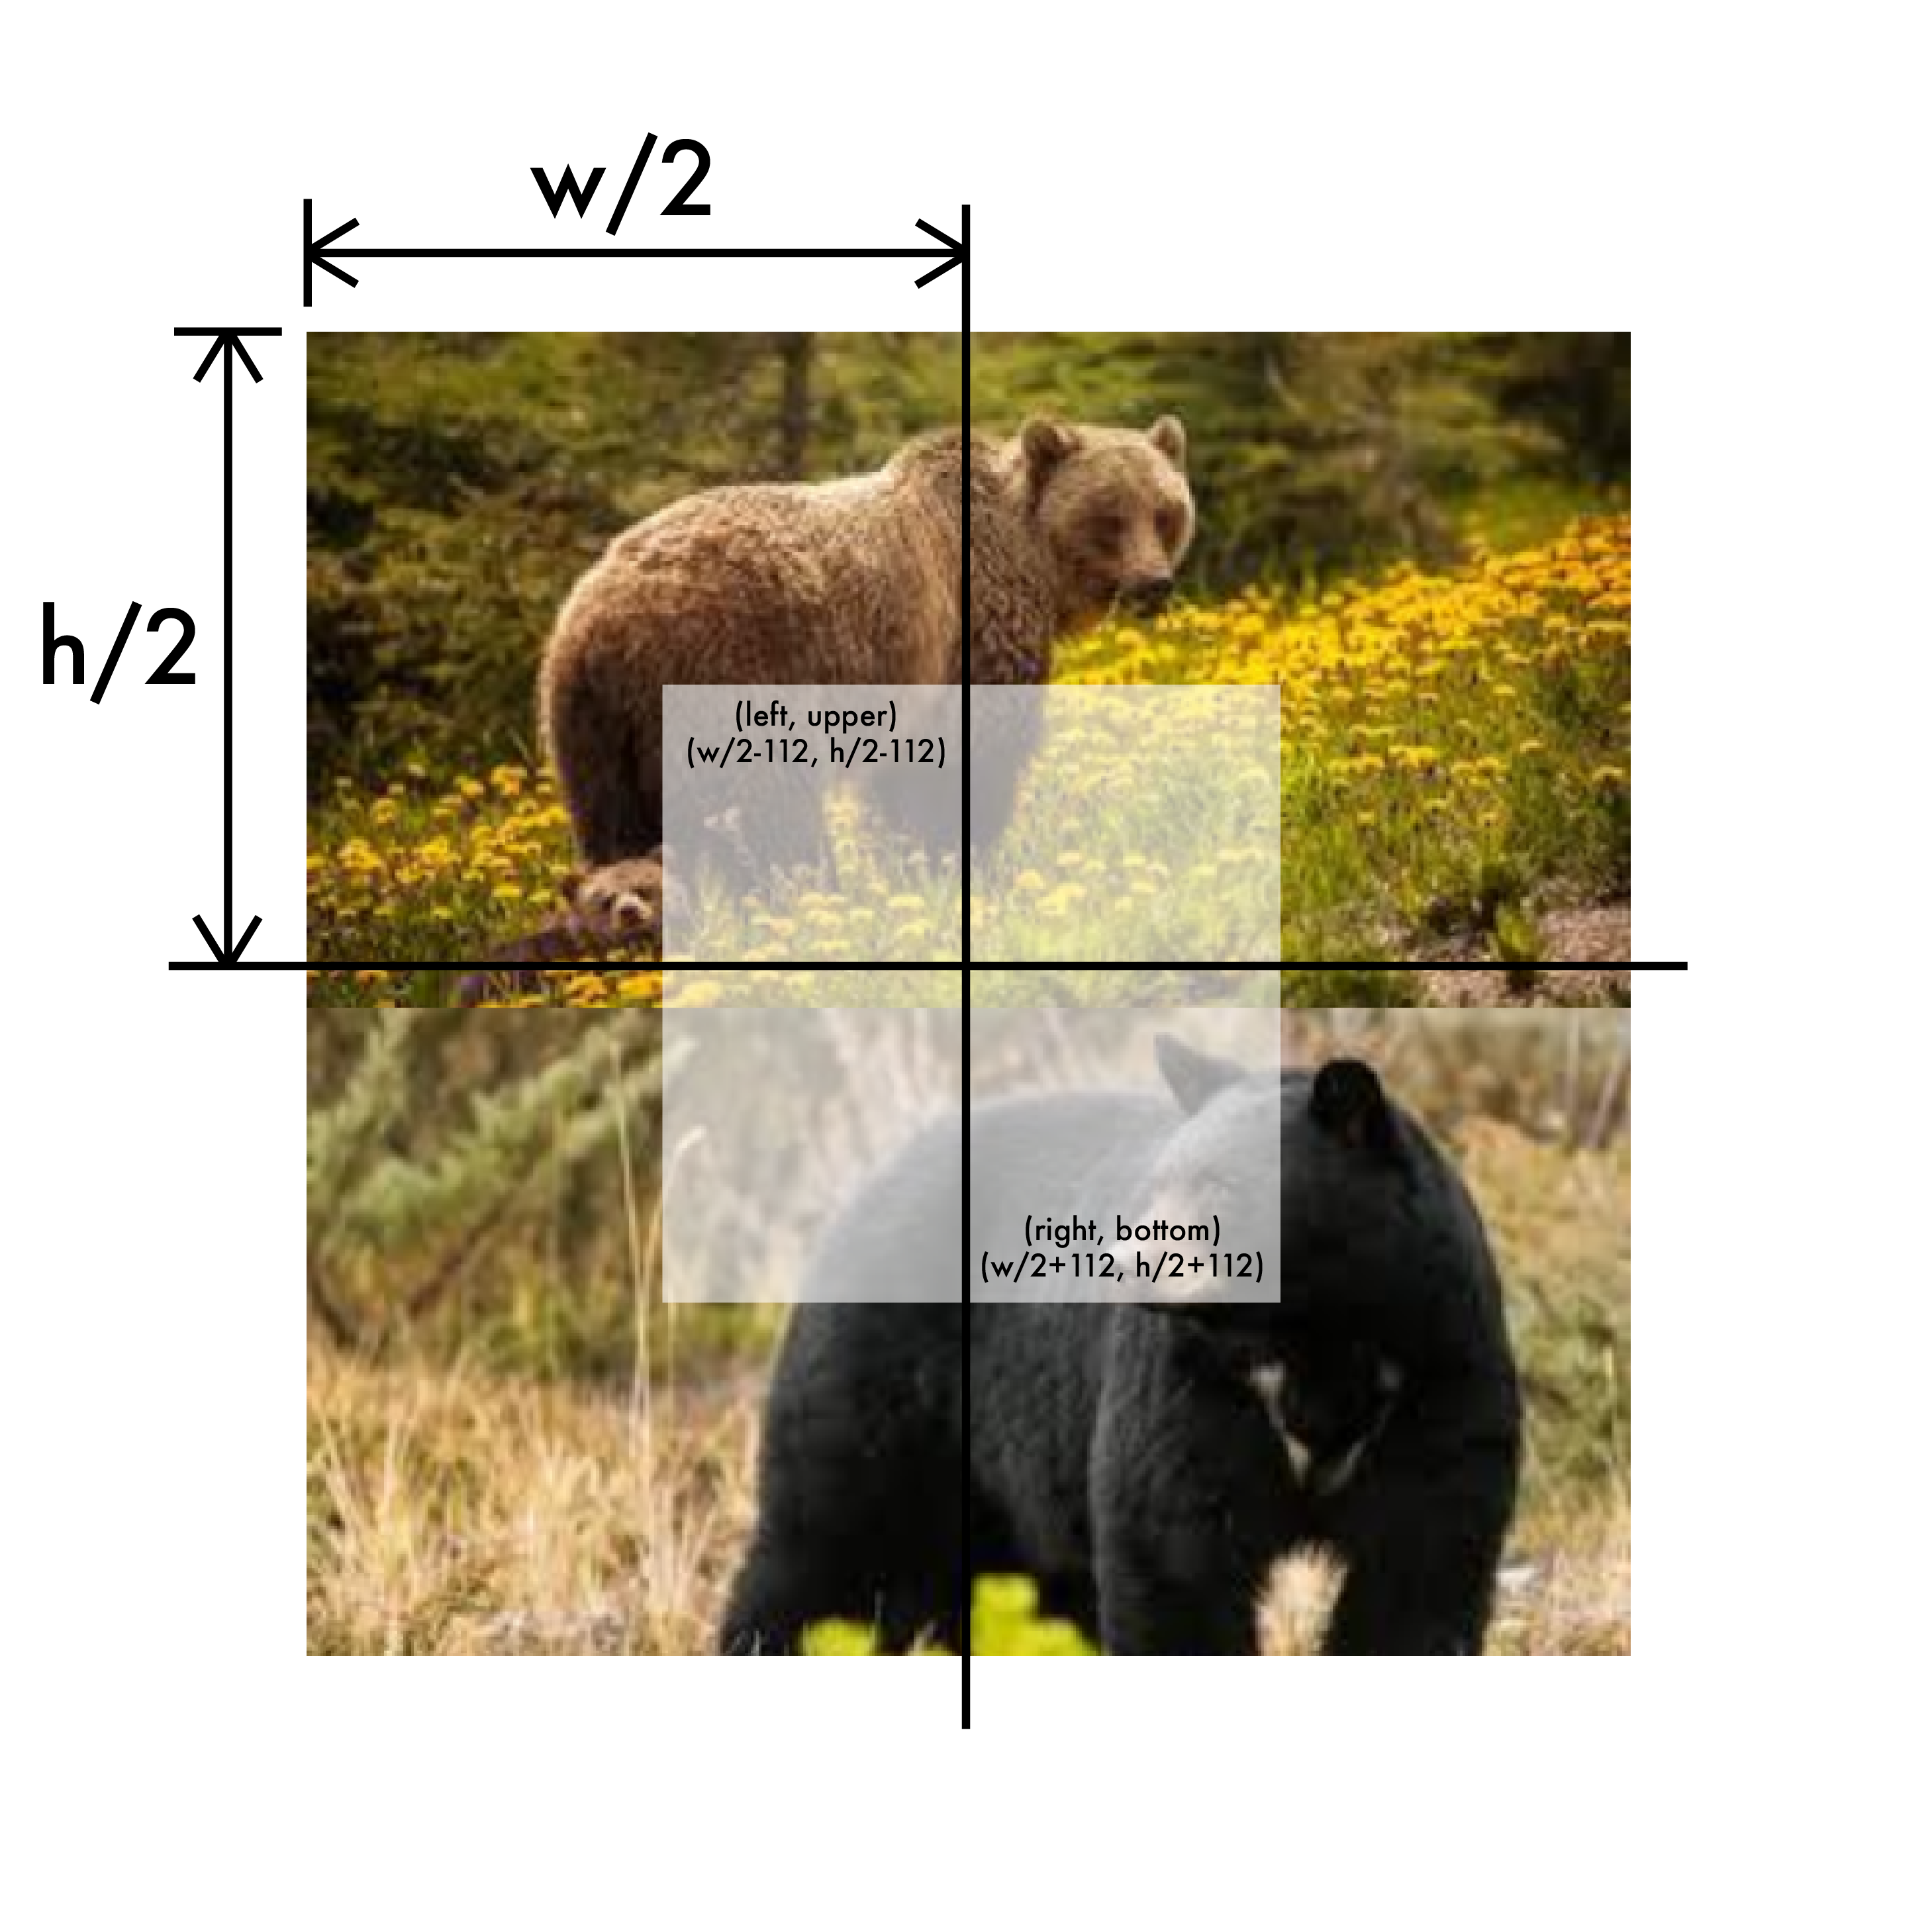

### Define a function which takes an image and returns a stacked `Tensor` with four corner crops and a center crop

I'll wrap those calls into a function which returns a Tensor with all 5 images:

In [ ]:
def corner_crop(img, size=224):
  """Returns a Tensor with 5 cropped square images
  img: PILImage
  size: int
  """
  w,h = img.width, img.height
  top_left = TensorImage(img.crop((0,0,size,size)))
  top_right = TensorImage(img.crop((w-size, 0, w, size)))
  bottom_right = TensorImage(img.crop((w-size, h-size, w, h)))
  bottom_left = TensorImage(img.crop((0, h-size, size, h)))
  center = TensorImage(img.crop((w/2-size/2, h/2-size/2, w/2+size/2,h/2+size/2)))
  return torch.stack([top_left, top_right, bottom_right, bottom_left, center])

In [ ]:
imgs = corner_crop(img)

# Top Left Corner Crop
imgs[0].show()

In [ ]:
# Top Right Corner Crop
imgs[1].show()

In [ ]:
# Bottom Right Corner Crop
imgs[2].show()

In [ ]:
# Bottom Left Corner Crop
imgs[3].show()

In [ ]:
# Center Crop
imgs[4].show()

### Define a new `CornerCrop` transform by extending the `Transform` class definition

In [ ]:
class CornerCrop(Transform):
    "Create 4 corner and 1 center crop of `size`"
    def __init__(self, size, corner_type=0, **kwargs):
      self.size = size
      self.corner_type = corner_type

    def encodes(self, x:(Image.Image,TensorBBox,TensorPoint)):
      self.w, self.h = x.size
      self.crops = [
                    x.crop((0,0,self.size, self.size)),
                    x.crop((self.w - self.size, 0, self.w, self.size)),
                    x.crop((self.w-self.size, self.h-self.size, self.w, self.h)),
                    x.crop((0, self.h-self.size, self.size, self.h))
                    ]
      return self.crops[self.corner_type]

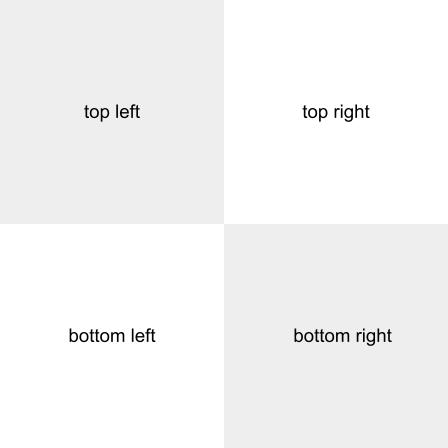

In [ ]:
# test image for CornerCrop
path = Path('/content/gdrive/MyDrive/fastai-course-v4/images/test/corner_crop_images')
Image.open((path/'01.jpg'))

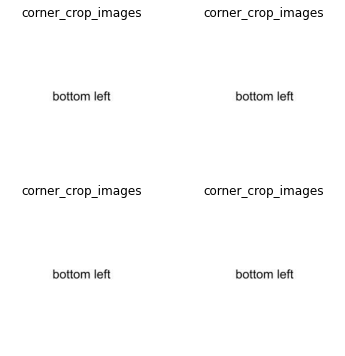

In [ ]:
# get the data
# path = untar_data(URLs.IMAGENETTE)
path = Path('/content/gdrive/MyDrive/fastai-course-v4/images/test/corner_crop_images')

# build the DataBlock and DataLoaders using CornerCrop
dblock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   get_items=get_image_files,
                   get_y=parent_label,
                   item_tfms=CornerCrop(224,3))

dls = dblock.dataloaders(path, bs=4)

# view a batch
dls.show_batch()

### Define a new `Learner.corner_crop_tta` method by repurposing the existing `Learner.tta` definition

I'll largely rely on the definition of `tta` in the built-in `Learner` class. In this method, predictions are calculated on four sets of augmented data (images) and then averaged along with predictions on a center-crop dataset. I will utilize the existing for-loop:

```python
for i in self.progress.mbar if hasattr(self,'progress') else range(n):
  self.epoch = i #To keep track of progress on mbar since the progress callback will use self.epoch
  aug_preds.append(self.get_preds(dl=dl, inner=True)[0][None])
```
Since I am cropping each dataset one corner at a time, I will set `n` to `4` and pass the loop counter `i` as the `corner_type` argument for the `CornerCrop` transform:

```python
aug_preds = []
for i in range(4):
  dl = dls[1].new(after_item=[CornerCrop(224,i), ToTensor])
  #self.epoch = i #To keep track of progress on mbar since the progress callback will use self.epoch
  aug_preds.append(learn.get_preds(dl=dl, inner=True)[0][None])
  ```

Since I am to average these with the center-crop image predictions, I'll create a new `DataLoader` without the `CornerCrop` transform and calculate the predictions on those images:

```python
dl = dls[1].new(shuffled=False, drop_last=False)
with dl.dataset.set_split_idx(1): preds,targs = learn.get_preds(dl=dl, inner=True)
```

Finally, I'll append the center crop `preds` to `aug_preds` list, concatenate them into a single tensor and take the mean of the predictions:

```python
aug_preds.append(preds[None])
preds = torch.cat(aug_preds).mean(0)
```

I decided to create a new `Learner2` class which extends the built-in the `Learner`, and added the `corner_crop_tta` method by copying over the `tta` method, commenting out the lines I won't need and adding the lines and changes I've written above.

In [ ]:
class Learner2(Learner):
  def corner_crop_tta(self:Learner, ds_idx=1, dl=None, n=4, beta=0.25, use_max=False):
      "Return predictions on the `ds_idx` dataset or `dl` using Corner Crop Test Time Augmentation"
      if dl is None: dl = self.dls[ds_idx].new(shuffled=False, drop_last=False)
      # if item_tfms is not None or batch_tfms is not None: dl = dl.new(after_item=item_tfms, after_batch=batch_tfms)
      try:
          #self(_before_epoch)
          with dl.dataset.set_split_idx(0), self.no_mbar():
              if hasattr(self,'progress'): self.progress.mbar = master_bar(list(range(n)))
              aug_preds = []
              # Crop image from four corners
              for i in self.progress.mbar if hasattr(self,'progress') else range(n):
                  dl = dl.new(after_item=[CornerCrop(224,i), ToTensor])
                  self.epoch = i #To keep track of progress on mbar since the progress callback will use self.epoch
                  aug_preds.append(self.get_preds(dl=dl, inner=True)[0][None])
         # aug_preds = torch.cat(aug_preds)
         # aug_preds = aug_preds.max(0)[0] if use_max else aug_preds.mean(0)
          self.epoch = n
          dl = self.dls[ds_idx].new(shuffled=False, drop_last=False)
          # Crop image from center
          with dl.dataset.set_split_idx(1): preds,targs = self.get_preds(dl=dl, inner=True)
          aug_preds.append(preds[None])
      finally: self(event.after_fit)

     # if use_max: return torch.stack([preds, aug_preds], 0).max(0)[0],targs
     # preds = (aug_preds,preds) if beta is None else torch.lerp(aug_preds, preds, beta)
     # preds = torch.cat([aug_preds, preds]).mean(0)
      preds = torch.cat(aug_preds).mean(0)
      return preds,targs

### Implement this new TTA method on the Imagenette classification model

In this section, I'll implement my TTA method on a image classification model trained on the Imagenette dataset.

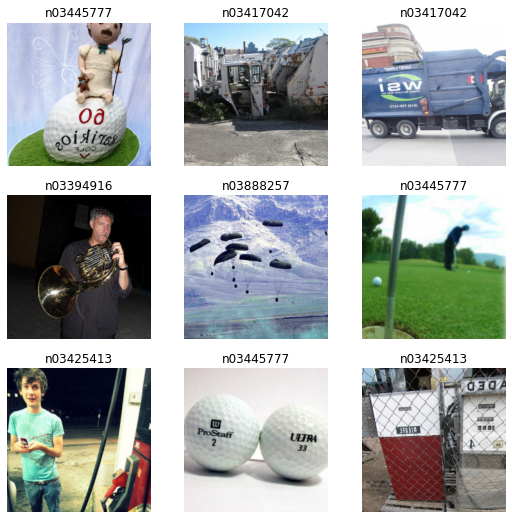

In [ ]:
# get the data
path = untar_data(URLs.IMAGENETTE)

# build the DataBlock and DataLoaders
dblock = DataBlock(blocks=(ImageBlock, CategoryBlock),
                   get_items=get_image_files,
                   get_y=parent_label,
                   item_tfms=Resize(460),
                   batch_tfms=aug_transforms(size=224, min_scale=0.75))

dls = dblock.dataloaders(path, bs=64)

# view a batch
dls.show_batch()

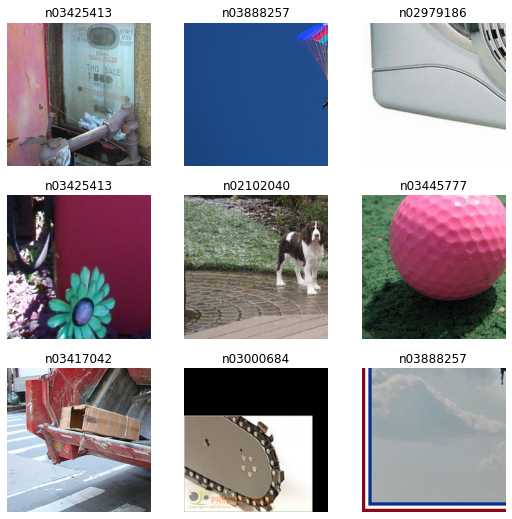

In [ ]:
# Try `CornerCrop` on a new DataLoader
# add `ToTensor` transform to conver PILImage to TensorImage
new_dl = dls[1].new(after_item=[CornerCrop(224,3), ToTensor])
new_dl.show_batch()

In [ ]:
# baseline training
model = xresnet50()
learn = Learner2(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn.fit_one_cycle(5, 3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.628959,2.382344,0.450336,02:39
1,1.258259,3.365233,0.386482,02:45
2,0.992097,1.129573,0.653473,02:49
3,0.709120,0.643617,0.802091,02:47
4,0.571318,0.571139,0.824122,02:45


In [ ]:
# built-in TTA method
preds_tta, targs_tta = learn.tta()
accuracy(preds_tta, targs_tta).item()

0.8345780372619629

In [ ]:
# user-defined TTA method
preds, targs = learn.corner_crop_tta()
accuracy(preds, targs).item()

0.7098581194877625

I'll walk through the `corner_crop_tta` code to verify the accuracy calculated above.

In [ ]:
# get predictions on corner cropped validation images
aug_preds = []
for i in range(4):
  dl = dls[1].new(after_item=[CornerCrop(224,i), ToTensor])
  #self.epoch = i #To keep track of progress on mbar since the progress callback will use self.epoch
  aug_preds.append(learn.get_preds(dl=dl, inner=True)[0][None])
len(aug_preds), aug_preds[0].shape

(4, torch.Size([1, 2678, 1000]))

In [ ]:
# get predictions on center crop validation images
dl = dls[1].new(shuffled=False, drop_last=False)
with dl.dataset.set_split_idx(1): preds,targs = learn.get_preds(dl=dl, inner=True)
preds.shape

torch.Size([2678, 1000])

In [ ]:
# add an axis to match augmented prediction tensor shape
preds = preds[None]
preds.shape

torch.Size([1, 2678, 1000])

In [ ]:
# average all 5 sets of predictions
aug_preds.append(preds)
preds = torch.cat(aug_preds).mean(0)

In [ ]:
# calculate validation set accuracy
accuracy(preds, targs).item()

0.7311426401138306

The following table summarize the results from this training:

|Validation|Accuracy|
|:-:|:-:|
|Center Crop|82.4%|
|Center Crop + 4 Random Crops: Linearly Interpolated|83.5%|
|Center Crop + 4 Random Crops: Averaged|73.1%|

Further Research:

- Fix the `corner_crop_tta` method so that it returns the same accuracy each time it's run on the same trained model
- Try `corner_crop_tta` on a multi-label classification dataset such as PASCAL
- Try linear interpolation (between center crop and corner crop maximum) instead of mean